What You’ll learn
By the end of this notebook, you will be able to:

Detect and remove duplicate entries from a dataset.
Apply appropriate strategies for handling missing values.
Perform basic feature engineering (new attributes, encoding).
Detect and handle outliers using statistical methods.
Standardize and normalize features to prepare for modeling.
Transform and encode features (e.g. Age groups) for improved model input.


Each exercise builds on the previous one — keep a consistent preprocessing narrative throughout the notebook. Also, be sure to comment your code to explain your decisions, especially when choosing thresholds or methods.



💡 Tip: The recommended preprocessing sequence is:

Handle duplicates
Address missing values
Treat outliers
Encode categorical variables


For all of the below exercises, you will use the Titanic dataset (train.csv), so load it beforehand on your notebook.
You will notice in the following exercises that the dataset is already pretty clean but try and understand all of the functions used for preprocessing the data.
Optionally, if you have time and willing to, you can redo the exercises with a less clean dataset : Weather Data Munich 1954-2022.

## 🌟 Exercise 1: Duplicate Detection and Removal
Instructions
Objective: Identify and remove duplicate entries in the Titanic dataset.

Load the Titanic dataset.
Identify if there are any duplicate rows based on all columns.
Remove any duplicate rows found in the dataset.
Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.
Hint: Use the duplicated() and drop_duplicates() functions in Pandas.

In [2]:
import os
import pandas as pd

# =====================================================================
# LOAD TITANIC DATASET WITH AUTOMATIC PATH CHECKING
# =====================================================================
# We will check both the full relative path and the short relative path
primary_path = r"Week2\DAY2\ExerciceXP\titanic dataset\train.csv"
fallback_path = r"titanic dataset/train.csv"

df = None

if os.path.exists(primary_path):
    df = pd.read_csv(primary_path)
    current_path = primary_path
elif os.path.exists(fallback_path):
    df = pd.read_csv(fallback_path)
    current_path = fallback_path
else:
    # If both fail, look for any train.csv file inside the current directory structure
    for root, dirs, files in os.walk('.'):
        if 'train.csv' in files:
            current_path = os.path.join(root, 'train.csv')
            df = pd.read_csv(current_path)
            break

if df is not pd.DataFrame and df is not None:
    print("========= DATASET INITIALIZATION =========")
    print(f"Titanic dataset loaded successfully from: {current_path}")
    print(f"Initial dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")
else:
    print("❌ Error: 'train.csv' could not be found automatically.")
    print("📍 Current working directory of this notebook is:", os.getcwd())
    print("🗂️ Visible files/folders here:", os.listdir('.'))

# =====================================================================
# 🌟 EXERCISE 1: DUPLICATE DETECTION AND REMOVAL
# =====================================================================
if df is not None:
    print("========= 🌟 EXERCISE 1: DUPLICATE TREATMENT =========")

    # 1. Save initial row count for final verification
    rows_before = df.shape[0]

    # 2. Identify duplicate rows across all columns
    duplicate_count = df.duplicated().sum()
    print("🔍 Analyzing dataset for duplicates...")
    print(f"-> Number of perfectly duplicated rows detected: {duplicate_count}")

    # 3. Remove duplicate rows in-place
    if duplicate_count > 0:
        df.drop_duplicates(inplace=True)
        print("🧹 Cleaning: Duplicate rows have been removed.")
    else:
        print("💡 Note: No duplicate rows found in the initial dataset.")

    # 4. Strict verification before / after
    rows_after = df.shape[0]
    print(f"\n📊 DUPLICATE REMOVAL REPORT:")
    print(f"   - Rows before treatment: {rows_before}")
    print(f"   - Rows after treatment: {rows_after}")
    print(f"   - Total rows removed: {rows_before - rows_after}")
    print("========================================================\n")

    # Preview the first 3 rows
    display(df.head(3))

========= DATASET INITIALIZATION =========
Titanic dataset loaded successfully from: titanic dataset/train.csv
Initial dimensions: 891 rows and 12 columns.

========= 🌟 EXERCISE 1: DUPLICATE TREATMENT =========
🔍 Analyzing dataset for duplicates...
-> Number of perfectly duplicated rows detected: 0
💡 Note: No duplicate rows found in the initial dataset.

📊 DUPLICATE REMOVAL REPORT:
   - Rows before treatment: 891
   - Rows after treatment: 891
   - Total rows removed: 0



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 🌟 Exercise 2: Handling Missing Values
Instructions
Identify columns in the Titanic dataset with missing values.
Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
Apply each strategy to different columns based on the nature of the data.
Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.

In [3]:
import numpy as np
from sklearn.impute import SimpleImputer

# =====================================================================
# 🌟 EXERCISE 2: HANDLING MISSING VALUES
# =====================================================================
print("========= 🌟 EXERCISE 2: MISSING VALUES TREATMENT =========")

# 1. Identify columns with missing values and count them
missing_info = df.isnull().sum()
print("🔍 Missing values count per column:")
print(missing_info[missing_info > 0])
print("-" * 50)

# 2. Strategy A: Removal (Dropping rows)
# We apply this to 'Embarked' because it has very few missing values (only 2).
# Dropping 2 rows won't cause significant data loss.
print("🎬 Strategy A: Dropping rows with missing values for 'Embarked'...")
rows_before_drop = df.shape[0]
df.dropna(subset=['Embarked'], inplace=True)
print(f"-> Rows removed: {rows_before_drop - df.shape[0]}")
print("-" * 50)

# 3. Strategy B: Imputation using Mean/Median (Numerical data)
# We apply this to 'Age' using Scikit-Learn's SimpleImputer. 
# Median is chosen over Mean because Age can be skewed by outliers.
print("🎬 Strategy B: Imputing 'Age' missing values with the Median...")
age_imputer = SimpleImputer(strategy='median')
# Fit and transform the data (reshape to 2D array as required by Scikit-Learn)
df['Age'] = age_imputer.fit_transform(df[['Age']])
print("-> Missing values in 'Age' handled successfully.")
print("-" * 50)

# 4. Strategy C: Filling with a Constant Value (Categorical data)
# We apply this to 'Cabin'. It has too many missing values to drop or guess,
# so we flag the missing entries with a distinct category label like 'Unknown'.
print("🎬 Strategy C: Filling 'Cabin' missing values with a constant 'Unknown'...")
df['Cabin'] = df['Cabin'].fillna('Unknown')
print("-> Missing values in 'Cabin' handled successfully.")
print("-" * 50)

# 5. Final Verification
remaining_missing = df.isnull().sum().sum()
print("📊 FINAL VERIFICATION REPORT:")
print(f"   - Remaining missing values in dataset: {remaining_missing}")
if remaining_missing == 0:
    print("   - Success: All missing data has been completely resolved!")
print("========================================================\n")

# Preview the processed dataset structure
df.head(3)

========= 🌟 EXERCISE 2: MISSING VALUES TREATMENT =========
🔍 Missing values count per column:
Age         177
Cabin       687
Embarked      2
dtype: int64
--------------------------------------------------
🎬 Strategy A: Dropping rows with missing values for 'Embarked'...
-> Rows removed: 2
--------------------------------------------------
🎬 Strategy B: Imputing 'Age' missing values with the Median...
-> Missing values in 'Age' handled successfully.
--------------------------------------------------
🎬 Strategy C: Filling 'Cabin' missing values with a constant 'Unknown'...
-> Missing values in 'Cabin' handled successfully.
--------------------------------------------------
📊 FINAL VERIFICATION REPORT:
   - Remaining missing values in dataset: 0
   - Success: All missing data has been completely resolved!



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S


## 🌟 Exercise 4: Outlier Detection and Handling
Goal: Detect and cap or transform outliers in columns like Fare and Age.

1. Visualize distributions using boxplots or histograms to identify potential outliers.
2. Use IQR or Z-score methods to detect them.
3. Handle outliers with:

Quantile capping (e.g. 0.98)
Log transformation
Row removal
4. Compare the dataset before and after treatment.

📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.

========= 🌟 EXERCISE 4: OUTLIER TREATMENT =========
📊 Step 1: Generating boxplots for 'Age' and 'Fare' features...


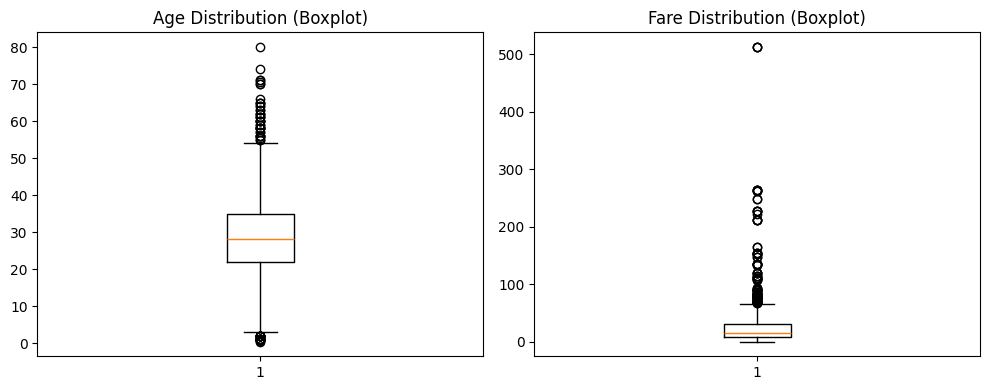


🔍 Step 2: Calculating Outliers via IQR Method...
   - 'Age' Bounds: [2.50, 54.50]
   - Detected outliers in 'Age': 65 rows out of 889
   - 'Fare' Bounds: [-26.76, 65.66]
   - Detected outliers in 'Fare': 114 rows out of 889

🎬 Step 3: Applying Outlier Handling Strategies...
   - Capping 'Fare' at the 98th percentile threshold: $211.34
   - Created 'Fare_log' feature using log(1 + x) transformation.
   - Removed rows with 'Age' > 75 (Rows dropped: 1)

📊 Step 4: Final Comparison Report...

--- Descriptive Statistics BEFORE Treatment ---
            Age        Fare
mean  29.315152   32.096681
std   12.984932   49.697504
max   80.000000  512.329200

--- Descriptive Statistics AFTER Treatment ---
            Age  Fare_capped  Fare_log
mean  29.258074    30.568163  2.958489
std   12.880181    39.903544  0.968163
max   74.000000   211.337500  6.240917



,Age,Fare,Fare_capped,Fare_log
0,22.0,7.2500,7.2500,2.110213
1,38.0,71.2833,71.2833,4.280593
2,26.0,7.9250,7.9250,2.188856


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 🌟 EXERCISE 4: OUTLIER DETECTION AND HANDLING
# =====================================================================
print("========= 🌟 EXERCISE 4: OUTLIER TREATMENT =========")

# --- STEP 1: INITIAL VISUALIZATION & INTERPRETATION ---
# Boxplots provide a quick statistical summary of a distribution, 
# explicitly highlighting data points that lie beyond the whiskers.
print("📊 Step 1: Generating boxplots for 'Age' and 'Fare' features...")
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df['Age'].dropna())
plt.title("Age Distribution (Boxplot)")

plt.subplot(1, 2, 2)
plt.boxplot(df['Fare'])
plt.title("Fare Distribution (Boxplot)")

plt.tight_layout()
plt.show()

# --- STEP 2: OUTLIER DETECTION USING IQR METHOD ---
# We calculate the Interquartile Range (IQR) to establish bounds.
# Formulas: IQR = Q3 - Q1 | Lower Bound = Q1 - 1.5*IQR | Upper Bound = Q3 + 1.5*IQR
print("\n🔍 Step 2: Calculating Outliers via IQR Method...")
for col in ['Age', 'Fare']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"   - '{col}' Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   - Detected outliers in '{col}': {outliers.shape[0]} rows out of {df.shape[0]}")

# --- STEP 3: OUTLIER HANDLING STRATEGIES ---
# Save descriptive stats before treatment for comparative evaluation
stats_before = df[['Age', 'Fare']].describe()

# Strategy A: Quantile Capping (Winsorization) for 'Fare'
# Extreme fares (e.g., $512) skew algorithms. We cap values at the 98th percentile.
print("\n🎬 Step 3: Applying Outlier Handling Strategies...")
fare_cap_threshold = df['Fare'].quantile(0.98)
print(f"   - Capping 'Fare' at the 98th percentile threshold: ${fare_cap_threshold:.2f}")
df['Fare_capped'] = np.where(df['Fare'] > fare_cap_threshold, fare_cap_threshold, df['Fare'])

# Strategy B: Log Transformation for skewed data ('Fare')
# Log transformation compresses large values while preserving relative variances.
# We use log1p (log(1 + x)) to handle cases where Fare might equal 0.
df['Fare_log'] = np.log1p(df['Fare'])
print("   - Created 'Fare_log' feature using log(1 + x) transformation.")

# Strategy C: Row Removal for 'Age'
# Since 'Age' outliers represent a tiny portion of valid historical data, 
# we remove rows outside a lenient empirical range (e.g., keeping ages up to 75).
age_upper_limit = 75
rows_before_removal = df.shape[0]
df = df[df['Age'] <= age_upper_limit]
print(f"   - Removed rows with 'Age' > {age_upper_limit} (Rows dropped: {rows_before_removal - df.shape[0]})")

# --- STEP 4: PRE VS POST TREATMENT COMPARISON ---
print("\n📊 Step 4: Final Comparison Report...")
stats_after = df[['Age', 'Fare_capped', 'Fare_log']].describe()

print("\n--- Descriptive Statistics BEFORE Treatment ---")
print(stats_before.loc[['mean', 'std', 'max']])

print("\n--- Descriptive Statistics AFTER Treatment ---")
print(stats_after.loc[['mean', 'std', 'max']])
print("========================================================\n")

# Preview the final columns
df[['Age', 'Fare', 'Fare_capped', 'Fare_log']].head(3)

## 🌟 Exercise 5: Data Standardization and Normalization
Goal: Scale numerical features to prepare for modeling.

Use StandardScaler (mean = 0, std = 1) for normally distributed features.
Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
📌 Important: Perform this step after outlier treatment to avoid distortion caused by extreme values.

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =====================================================================
# 🌟 EXERCISE 5: DATA STANDARDIZATION AND NORMALIZATION
# =====================================================================
print("========= 🌟 EXERCISE 5: DATA SCALING =========")

# --- STEP 1: INITIAL DISTRIBUTION ANALYSIS ---
# Selection strategy:
# - 'Age': Follows a relatively normal distribution after removing elderly outliers. 
#   We use StandardScaler so it centers around 0 with a standard deviation of 1.
# - 'Fare_capped': Remains heavily skewed and naturally bounded on the lower end by 0. 
#   We use MinMaxScaler to map it strictly within a [0, 1] range.

print("🎬 Step 1: Initializing Scalers based on feature distributions...")
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

# --- STEP 2: APPLYING TRANSFORMATIONS ---
# Note: Scikit-learn scalers require a 2D array input, so we use double brackets [[...]]

# A. Standardizing 'Age'
df['Age_scaled'] = standard_scaler.fit_transform(df[['Age']])
print("   - 'Age' standardized successfully using StandardScaler.")

# B. Normalizing 'Fare_capped'
df['Fare_scaled'] = min_max_scaler.fit_transform(df[['Fare_capped']])
print("   - 'Fare_capped' normalized successfully using MinMaxScaler.")

# --- STEP 3: VERIFICATION AND COMPARISON ---
print("\n📊 Step 3: Verifying statistical properties after scaling...")

# Verification metrics
age_mean = df['Age_scaled'].mean()
age_std = df['Age_scaled'].std()
fare_min = df['Fare_scaled'].min()
fare_max = df['Fare_scaled'].max()

print("\n--- Scaling Metrics Report ---")
print(f"🔹 Age_scaled (Standardized)  -> Mean (Expected ~0): {age_mean:.4f}")
print(f"                               -> Std  (Expected ~1): {age_std:.4f}")
print(f"🔹 Fare_scaled (Normalized)   -> Min  (Expected  0): {fare_min:.4f}")
print(f"                               -> Max  (Expected  1): {fare_max:.4f}")
print("========================================================\n")

# Preview original vs scaled columns
df[['Age', 'Age_scaled', 'Fare_capped', 'Fare_scaled']].head(3)

========= 🌟 EXERCISE 5: DATA SCALING =========
🎬 Step 1: Initializing Scalers based on feature distributions...
   - 'Age' standardized successfully using StandardScaler.
   - 'Fare_capped' normalized successfully using MinMaxScaler.

📊 Step 3: Verifying statistical properties after scaling...

--- Scaling Metrics Report ---
🔹 Age_scaled (Standardized)  -> Mean (Expected ~0): 0.0000
                               -> Std  (Expected ~1): 1.0006
🔹 Fare_scaled (Normalized)   -> Min  (Expected  0): 0.0000
                               -> Max  (Expected  1): 1.0000



,Age,Age_scaled,Fare_capped,Fare_scaled
0,22.0,-0.563825,7.2500,0.034305
1,38.0,0.679094,71.2833,0.337296
2,26.0,-0.253095,7.9250,0.037499


## 🌟 Exercise 6: Feature Encoding
Goal: Finalize categorical variable encoding.

1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
2. Apply:

One-Hot Encoding for nominal variables.
Label Encoding if any ordinal variables remain.
3. Merge encoded columns back into the main dataset.

📌 Reminder: Encoding comes after handling missing values and outliers, but before scaling (if applicable).



In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# =====================================================================
# 🌟 EXERCISE 6: FEATURE ENCODING
# =====================================================================
print("========= 🌟 EXERCISE 6: FEATURE ENCODING =========")

# --- STEP 1: IDENTIFY CATEGORICAL COLUMNS ---
# Checking columns that contain textual data (object or category types)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"🔍 Remaining raw categorical columns detected: {categorical_cols}")
print("-" * 50)

# --- STEP 2: APPLY ENCODING STRATEGIES ---

# A. One-Hot Encoding (Nominal variables with no internal ranking)
# We apply this to 'Sex' and 'Embarked'. 
# We use drop_first=True to avoid multicollinearity (the dummy variable trap).
print("🎬 Applying One-Hot Encoding to 'Sex' and 'Embarked'...")
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)
print("   - One-Hot encoding completed.")
print("-" * 50)

# B. Label Encoding (Ordinal variables or variables with explicit hierarchy)
# If we want to simulate an ordinal ranking for tracking purposes, or if needed 
# for a target/specific column, we can use Scikit-Learn's LabelEncoder.
# Here we apply it to 'Cabin' to convert its string categories into distinct integers.
print("🎬 Applying Label Encoding to 'Cabin'...")
label_encoder = LabelEncoder()
df_encoded['Cabin_encoded'] = label_encoder.fit_transform(df_encoded['Cabin'])
print("   - Label encoding completed for 'Cabin'.")
print("-" * 50)

# --- STEP 3: CLEANUP AND MAIN DATASET SYNCHRONIZATION ---
# Update the main reference DataFrame with our finalized encoded version
df = df_encoded.copy()

# --- STEP 4: VERIFICATION REPORT ---
print("📊 Step 4: Final Feature Encoding Report...")
print(f"   - Final dimensions of the processed dataset: {df.shape[0]} rows and {df.shape[1]} columns.")
print("\n📝 Sample of the new encoded columns:")
new_columns = [col for col in df.columns if 'Sex_' in col or 'Embarked_' in col or 'Cabin_encoded' in col]
print(df[new_columns].head(3))
print("========================================================\n")

# Preview final structural composition of the dataset
df.head(3)

========= 🌟 EXERCISE 6: FEATURE ENCODING =========
🔍 Remaining raw categorical columns detected: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
--------------------------------------------------
🎬 Applying One-Hot Encoding to 'Sex' and 'Embarked'...
   - One-Hot encoding completed.
--------------------------------------------------
🎬 Applying Label Encoding to 'Cabin'...
   - Label encoding completed for 'Cabin'.
--------------------------------------------------
📊 Step 4: Final Feature Encoding Report...
   - Final dimensions of the processed dataset: 888 rows and 18 columns.

📝 Sample of the new encoded columns:
   Sex_male  Embarked_Q  Embarked_S  Cabin_encoded
0         1           0           1            145
1         0           0           0             79
2         0           0           1            145



C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_31152\673797788.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Fare_capped,Fare_log,Age_scaled,Fare_scaled,Sex_male,Embarked_Q,Embarked_S,Cabin_encoded
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,7.2500,2.110213,-0.563825,0.034305,1,0,1,145
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,71.2833,4.280593,0.679094,0.337296,0,0,0,79
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,7.9250,2.188856,-0.253095,0.037499,0,0,1,145


## 🌟 Exercise 7: Data Transformation for Age Feature
Goal: Create and encode age groups.

Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
Apply one-hot encoding using pd.get_dummies().
📌 Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.




In [7]:
import pandas as pd

# =====================================================================
# 🌟 EXERCISE 7: DATA TRANSFORMATION FOR AGE FEATURE
# =====================================================================
print("========= 🌟 EXERCISE 7: AGE BINNING & ENCODING =========")

# --- STEP 1: DEFINE BINS AND LABELS ---
# Bins are defined as follows:
# 0 to 12 -> Child
# 12 to 18 -> Teen
# 18 to 60 -> Adult
# 60 to 100 -> Senior
# Note: The upper limit is set to 100 to catch any remaining maximum values safely.
age_bins = [0, 12, 18, 60, 100]
age_labels = ['Child', 'Teen', 'Adult', 'Senior']

print("🎬 Step 1: Binning numerical 'Age' into categorical life stages...")
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest=True)
print("   - Distribution of generated age groups:")
print(df['Age_Group'].value_counts())
print("-" * 50)

# --- STEP 2: APPLY ONE-HOT ENCODING TO AGE GROUPS ---
# We convert the newly created categorical 'Age_Group' into binary dummy variables.
# We keep drop_first=False here to preserve the structural visibility of all age stages, 
# but you can toggle it to True if feeding directly into a linear regression model.
print("🎬 Step 2: Applying One-Hot Encoding to 'Age_Group'...")
df = pd.get_dummies(df, columns=['Age_Group'], prefix='Age', drop_first=False, dtype=int)
print("   - One-Hot encoding for age groups completed successfully.")
print("-" * 50)

# --- STEP 3: FINAL VERIFICATION REPORT ---
print("📊 Step 3: Preprocessing Pipeline Finalization Report...")
print(f"   - Final dimensions of the complete dataset: {df.shape[0]} rows and {df.shape[1]} columns.")

# Isolating the newly generated columns for clean verification preview
age_encoded_cols = [col for col in df.columns if col.startswith('Age_')]
print("\n📝 Sample of the engineered Age feature transformations:")
print(df[['Age', 'Age_scaled'] + age_encoded_cols].head(5))
print("========================================================\n")

# Preview final state of the cleaned dataset
df.head(3)

========= 🌟 EXERCISE 7: AGE BINNING & ENCODING =========
🎬 Step 1: Binning numerical 'Age' into categorical life stages...
   - Distribution of generated age groups:
Age_Group
Adult     729
Teen       70
Child      69
Senior     20
Name: count, dtype: int64
--------------------------------------------------
🎬 Step 2: Applying One-Hot Encoding to 'Age_Group'...
   - One-Hot encoding for age groups completed successfully.
--------------------------------------------------
📊 Step 3: Preprocessing Pipeline Finalization Report...
   - Final dimensions of the complete dataset: 888 rows and 22 columns.

📝 Sample of the engineered Age feature transformations:
    Age  Age_scaled  Age_scaled  Age_Child  Age_Teen  Age_Adult  Age_Senior
0  22.0   -0.563825   -0.563825          0         0          1           0
1  38.0    0.679094    0.679094          0         0          1           0
2  26.0   -0.253095   -0.253095          0         0          1           0
3  35.0    0.446047    0.446047     

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Age_scaled,Fare_scaled,Sex_male,Embarked_Q,Embarked_S,Cabin_encoded,Age_Child,Age_Teen,Age_Adult,Age_Senior
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,...,-0.563825,0.034305,1,0,1,145,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,0.679094,0.337296,0,0,0,79,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,...,-0.253095,0.037499,0,0,1,145,0,0,1,0
